# RF vs. GNN — Summary Figures (Heatmaps & Bar Chart)

Produces the three summary figures from the 10-seed multi-run significance analysis:

- **Figure 1** — 3-panel heatmap (precision / recall / F1), GNN − RF difference per architecture × class
- **Figure 2** — Overall accuracy & MCC bar chart (mean ± std across 10 runs) vs. RF's fixed value
- **Figure 3** — Standalone F1 heatmap (the "key table")

**Requires:** `FINAL_overall_ttest_vs_RF.csv` and `FINAL_per_class_ttest_vs_RF.csv` (produced by the multi-run t-test analysis) in the same folder as this notebook, or update the paths in the cell below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
})

## 1. Load data

In [2]:
overall_path = "FINAL_overall_ttest_vs_RF.csv"
per_class_path = "FINAL_per_class_ttest_vs_RF.csv"

overall = pd.read_csv(overall_path)
per_class = pd.read_csv(per_class_path)

architectures = ["GCN", "GAT", "GINE", "GraphSAGE"]
classes = ["AA", "AI", "IA", "II"]
metrics = ["precision", "recall", "f1"]

# Random Forest's fixed (deterministic) reference values
RF_ACC, RF_MCC = 0.7257, 0.6019

overall.head()

,Architecture,Metric,RF,GNN_mean,GNN_std,t_stat,p_value
0,GCN,Accuracy,0.7257,0.729204,0.014782,0.711057,0.495063
1,GCN,MCC,0.6019,0.606251,0.022909,0.569813,0.582746
2,GAT,Accuracy,0.7257,0.740708,0.010693,4.210606,0.002271
3,GAT,MCC,0.6019,0.626219,0.015336,4.757071,0.001034
4,GINE,Accuracy,0.7257,0.703540,0.017251,-3.853727,0.003884


## 2. Figure 1 — Per-class heatmap (precision / recall / F1), GNN − RF

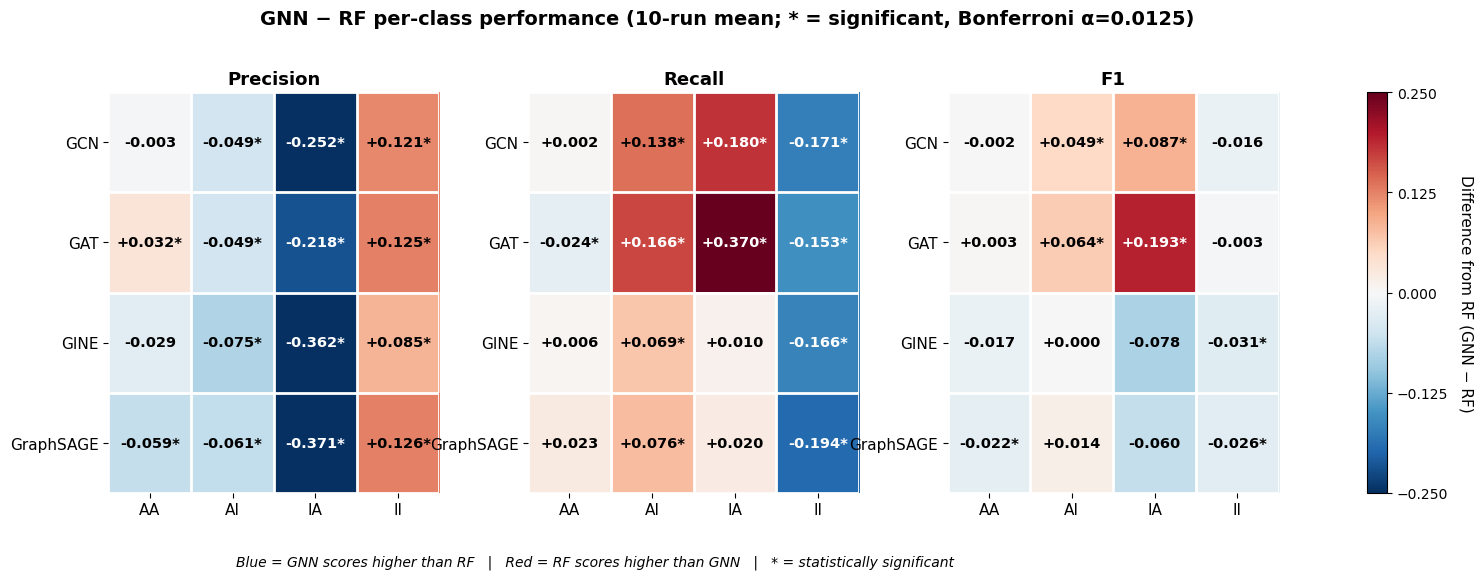

Saved: Figure1_per_class_heatmap.png


In [3]:
cmap = plt.cm.RdBu_r  # blue = GNN higher, red = RF higher
norm = TwoSlopeNorm(vmin=-0.25, vcenter=0, vmax=0.25)

# gridspec reserves a dedicated narrow column for the colorbar so it never
# overlaps the third (F1) heatmap
fig = plt.figure(figsize=(16.5, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])

im = None
for ax, metric in zip(axes, metrics):
    mat = np.zeros((len(architectures), len(classes)))
    annot = np.empty((len(architectures), len(classes)), dtype=object)
    for i, arch in enumerate(architectures):
        for j, cls in enumerate(classes):
            row = per_class[(per_class.Architecture == arch) &
                             (per_class.Class == cls) &
                             (per_class.Metric == metric)].iloc[0]
            mat[i, j] = row["diff"]
            star = "*" if row["significant_bonf"] else ""
            annot[i, j] = f"{row['diff']:+.3f}{star}"

    im = ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticks(range(len(architectures)))
    ax.set_yticklabels(architectures)
    ax.set_title(metric.capitalize())

    for i in range(len(architectures)):
        for j in range(len(classes)):
            ax.text(j, i, annot[i, j], ha="center", va="center",
                     fontsize=10.5, fontweight="bold",
                     color="white" if abs(mat[i, j]) > 0.15 else "black")

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(architectures), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", size=0)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Difference from RF (GNN \u2212 RF)", rotation=270, labelpad=18, fontsize=11)
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks([-0.25, -0.125, 0, 0.125, 0.25])

fig.suptitle("GNN \u2212 RF per-class performance (10-run mean; * = significant, Bonferroni \u03b1=0.0125)",
             fontsize=14, fontweight="bold", y=1.04)
fig.text(0.42, -0.03,
         "Blue = GNN scores higher than RF   |   Red = RF scores higher than GNN   |   * = statistically significant",
         ha="center", fontsize=10, style="italic")

fig.savefig("Figure1_per_class_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()
print("Saved: Figure1_per_class_heatmap.png")

## 3. Figure 2 — Overall accuracy & MCC (mean ± std across 10 runs) vs. RF

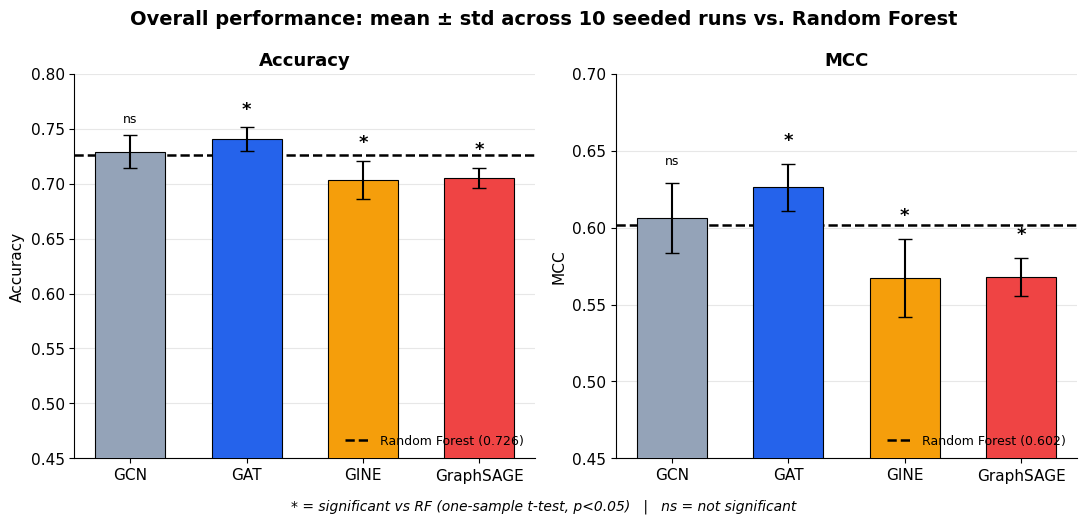

Saved: Figure2_overall_performance.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

colors = {"GCN": "#94a3b8", "GAT": "#2563eb", "GINE": "#f59e0b", "GraphSAGE": "#ef4444"}

for ax, metric, rf_val in zip(axes, ["Accuracy", "MCC"], [RF_ACC, RF_MCC]):
    sub = overall[overall.Metric == metric].set_index("Architecture").loc[architectures]
    x = np.arange(len(architectures))
    bar_colors = [colors[a] for a in architectures]
    ax.bar(x, sub["GNN_mean"], yerr=sub["GNN_std"], capsize=5,
           color=bar_colors, edgecolor="black", linewidth=0.8, width=0.6, zorder=3)

    ax.axhline(rf_val, color="black", linestyle="--", linewidth=1.8, zorder=2,
               label=f"Random Forest ({rf_val:.3f})")

    for i, arch in enumerate(architectures):
        p = sub.loc[arch, "p_value"]
        sig = p < 0.05
        y = sub.loc[arch, "GNN_mean"] + sub.loc[arch, "GNN_std"] + 0.012
        marker = "*" if sig else "ns"
        weight = "bold" if sig else "normal"
        ax.text(i, y, marker, ha="center", fontsize=13 if sig else 9, fontweight=weight)

    ax.set_xticks(x)
    ax.set_xticklabels(architectures)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0.45, 0.80 if metric == "Accuracy" else 0.70)
    ax.legend(loc="lower right", fontsize=9, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3, zorder=0)

fig.suptitle("Overall performance: mean \u00b1 std across 10 seeded runs vs. Random Forest",
             fontsize=14, fontweight="bold")
fig.text(0.5, -0.02, "* = significant vs RF (one-sample t-test, p<0.05)   |   ns = not significant",
         ha="center", fontsize=10, style="italic")
fig.tight_layout()

fig.savefig("Figure2_overall_performance.png", dpi=220, bbox_inches="tight")
plt.show()
print("Saved: Figure2_overall_performance.png")

## 4. Figure 3 — Standalone F1 heatmap (the "key table")

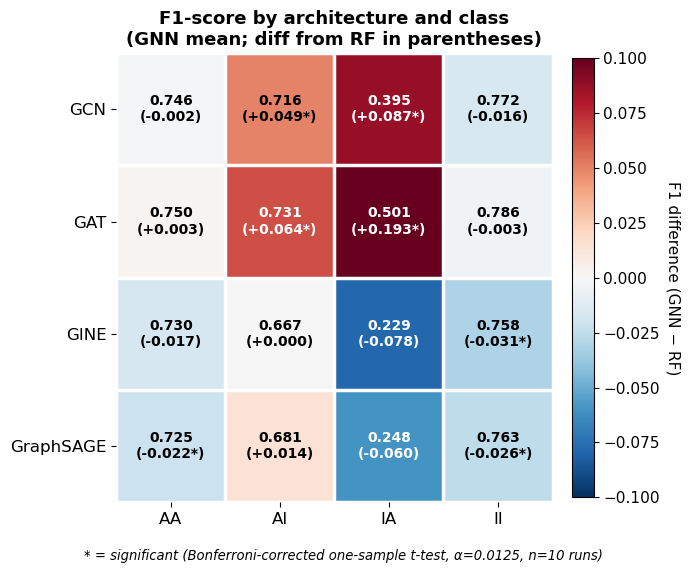

Saved: Figure3_F1_heatmap_key.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))

mat = np.zeros((len(architectures), len(classes)))
annot = np.empty((len(architectures), len(classes)), dtype=object)
for i, arch in enumerate(architectures):
    for j, cls in enumerate(classes):
        row = per_class[(per_class.Architecture == arch) &
                         (per_class.Class == cls) &
                         (per_class.Metric == "f1")].iloc[0]
        mat[i, j] = row["diff"]
        star = "*" if row["significant_bonf"] else ""
        annot[i, j] = f"{row['GNN_mean']:.3f}\n({row['diff']:+.3f}{star})"

norm2 = TwoSlopeNorm(vmin=-0.10, vcenter=0, vmax=0.10)
im = ax.imshow(mat, cmap=cmap, norm=norm2, aspect="auto")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, fontsize=12)
ax.set_yticks(range(len(architectures)))
ax.set_yticklabels(architectures, fontsize=12)
ax.set_title("F1-score by architecture and class\n(GNN mean; diff from RF in parentheses)", fontsize=13)

for i in range(len(architectures)):
    for j in range(len(classes)):
        ax.text(j, i, annot[i, j], ha="center", va="center", fontsize=10, fontweight="bold",
                 color="white" if abs(mat[i, j]) > 0.06 else "black")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(architectures), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2.5)
ax.tick_params(which="minor", size=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("F1 difference (GNN \u2212 RF)", rotation=270, labelpad=15)

fig.text(0.5, -0.03, "* = significant (Bonferroni-corrected one-sample t-test, \u03b1=0.0125, n=10 runs)",
         ha="center", fontsize=9.5, style="italic")
fig.tight_layout()

fig.savefig("Figure3_F1_heatmap_key.png", dpi=220, bbox_inches="tight")
plt.show()
print("Saved: Figure3_F1_heatmap_key.png")